# Preparación de datos — Beijing PM2.5

Este notebook transforma los registros horarios de 12 estaciones en datos temporales limpios y ventanas preparadas para entrenar modelos de deep learning. El proceso incluye la consolidación y el orden temporal, la partición cronológica, la imputación de faltantes, la estandarización, la construcción y validación de ventanas, y el guardado de los resultados.

Como entrada se utilizan los archivos `PRSA_Data_<Estacion>_20130301-20170228.csv`. Como salida se generan `train.csv`, `val.csv`, `test.csv` y tensores PyTorch para las configuraciones 24h→1h y 48h→6h. 

Todas las transformaciones que aprenden parámetros se ajustan únicamente con entrenamiento y se aplican después a validación y prueba, preservando la causalidad temporal y evitando la fuga de información.

## 1. Entorno y reproducibilidad

In [1]:
import sys
import platform
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import torch
from pathlib import Path

SEED = 8
np.random.seed(SEED)
torch.manual_seed(SEED)

print("Python:", sys.version.split()[0])
print("Plataforma:", platform.platform())
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("torch:", torch.__version__)
print("matplotlib:", matplotlib.__version__)
print("Semilla fijada:", SEED)

FEATURES = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
            "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]
TARGET = "PM2.5"

print("\nFeatures usadas:", FEATURES)
print("Variable objetivo:", TARGET)

Python: 3.10.13
Plataforma: macOS-26.6.2-arm64-arm-64bit
pandas: 2.2.1
numpy: 1.26.4
torch: 2.13.0
matplotlib: 3.8.3
Semilla fijada: 8

Features usadas: ['PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM']
Variable objetivo: PM2.5


## 2. Cargar y consolidar las 12 estaciones

Se cargan los 12 archivos, se construye un índice `datetime` a partir de las columnas `year`, `month`, `day`, `hour`, y se ordena explícitamente por estación y por tiempo.

In [2]:
DATA_DIR = Path("data/beijing+multi+site+air+quality+data")

archivos = sorted(DATA_DIR.glob("PRSA_Data_*.csv"))
print(f"Archivos encontrados: {len(archivos)}")

dfs = []
for f in archivos:
    d = pd.read_csv(f)
    d["datetime"] = pd.to_datetime(d[["year", "month", "day", "hour"]])
    dfs.append(d)

df = pd.concat(dfs, ignore_index=True)

# Orden explícito: primero por estación, luego por tiempo dentro de cada estación
df = df.sort_values(["station", "datetime"]).reset_index(drop=True)

print("Dimensiones:", df.shape)
print("Rango temporal:", df["datetime"].min(), "a", df["datetime"].max())
print("Estaciones:", df["station"].nunique())


Archivos encontrados: 12
Dimensiones: (420768, 19)
Rango temporal: 2013-03-01 00:00:00 a 2017-02-28 23:00:00
Estaciones: 12


In [3]:
# Verificación de orden: dentro de cada estación, el datetime debe ser estrictamente creciente
orden_correcto = df.groupby("station")["datetime"].apply(lambda s: s.is_monotonic_increasing).all()
assert orden_correcto, "El orden temporal dentro de alguna estación no es creciente."
print("Orden temporal verificado dentro de cada estación: OK")

Orden temporal verificado dentro de cada estación: OK


> Se consolidaron 12 estaciones y 420.768 registros en el período 2013–2017. El orden cronológico quedó verificado antes de crear las particiones.

## 3. Partición temporal

Los conjuntos se separan por fecha, nunca de forma aleatoria, para reproducir el uso real: entrenar con el pasado y predecir el futuro.

- **Entrenamiento:** marzo de 2013 a febrero de 2016 (~75%)
- **Validación:** marzo a agosto de 2016 (~12.5%)
- **Prueba:** septiembre de 2016 a febrero de 2017 (~12.5%)

Así, el modelo se evalúa siempre sobre períodos posteriores al entrenamiento.

In [4]:
TRAIN_END = "2016-02-29 23:00:00"
VAL_END = "2016-08-31 23:00:00"

train = df[df["datetime"] <= TRAIN_END].reset_index(drop=True)
val = df[(df["datetime"] > TRAIN_END) & (df["datetime"] <= VAL_END)].reset_index(drop=True)
test = df[df["datetime"] > VAL_END].reset_index(drop=True)

print(f"Train: {train['datetime'].min()} a {train['datetime'].max()}  |  {len(train):,} filas")
print(f"Val:   {val['datetime'].min()} a {val['datetime'].max()}  |  {len(val):,} filas")
print(f"Test:  {test['datetime'].min()} a {test['datetime'].max()}  |  {len(test):,} filas")

Train: 2013-03-01 00:00:00 a 2016-02-29 23:00:00  |  315,648 filas
Val:   2016-03-01 00:00:00 a 2016-08-31 23:00:00  |  52,992 filas
Test:  2016-09-01 00:00:00 a 2017-02-28 23:00:00  |  52,128 filas


In [5]:
# Verificaciones de integridad de la partición
assert train["datetime"].max() < val["datetime"].min(), "Traslape entre train y val"
assert val["datetime"].max() < test["datetime"].min(), "Traslape entre val y test"
assert len(train) + len(val) + len(test) == len(df), "Se perdieron o duplicaron filas al particionar"

print("Sin traslape entre conjuntos: OK")
print("Suma de filas = total original: OK")

Sin traslape entre conjuntos: OK
Suma de filas = total original: OK


> Las particiones no se solapan y conservan todas las filas originales. Esta separación reproduce el escenario real: predecir períodos futuros a partir del pasado.

## 4. Verificación de las particiones

La gráfica resume la serie completa y marca los tres periodos. Las comprobaciones anteriores garantizan que no haya solapamiento, que se conserve el número total de filas y que la cronología avance de entrenamiento a validación y prueba.

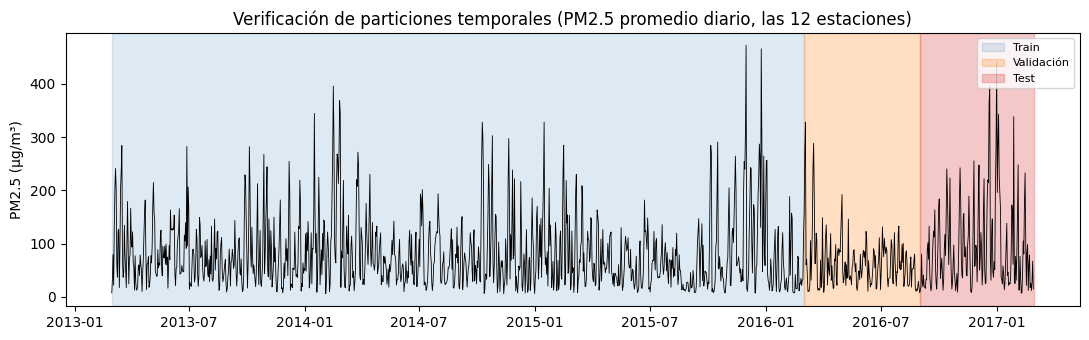

In [6]:
serie_diaria = (df.groupby(pd.Grouper(key="datetime", freq="D"))["PM2.5"].mean())

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(serie_diaria.index, serie_diaria.values, color="black", linewidth=0.6)

ax.axvspan(train["datetime"].min(), train["datetime"].max(), color="tab:blue", alpha=0.15, label="Train")
ax.axvspan(val["datetime"].min(), val["datetime"].max(), color="tab:orange", alpha=0.25, label="Validación")
ax.axvspan(test["datetime"].min(), test["datetime"].max(), color="tab:red", alpha=0.25, label="Test")

ax.set_title("Verificación de particiones temporales (PM2.5 promedio diario, las 12 estaciones)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(fontsize=8, loc="upper right")
plt.tight_layout()
plt.show()

del df


> Las franjas muestran la progresión continua de entrenamiento, validación y prueba. No se observa una mezcla temporal entre conjuntos.

## 5. Valores faltantes

Antes de imputar se cuantifican los `NaN` por variable. Este conteo sirve como línea base para distinguir los faltantes originales del efecto de la limpieza.

In [7]:
cols_medicion = ["PM2.5", "PM10", "SO2", "NO2", "CO", "O3",
                  "TEMP", "PRES", "DEWP", "RAIN", "WSPM"]

na_antes = train[cols_medicion].isna().sum()
print("Valores faltantes por variable (antes de imputar):")
print(na_antes)
print("\nTotal NA:", na_antes.sum(), f"({na_antes.sum() / (len(train) * len(cols_medicion)) * 100:.2f}% de las celdas)")

Valores faltantes por variable (antes de imputar):
PM2.5     6372
PM10      4615
SO2       6987
NO2       9659
CO       18106
O3       10177
TEMP       179
PRES       180
DEWP       184
RAIN       176
WSPM       178
dtype: int64

Total NA: 56813 (1.64% de las celdas)


> Este conteo establece la línea base de datos faltantes

## 6. Imputación temporal

Se interpolan únicamente huecos de hasta seis horas dentro de cada estación. Los huecos más largos se completan con la mediana de la misma estación y hora, calculada con `train`.

La combinación conserva la continuidad local cuando hay suficiente evidencia y evita extrapolar durante periodos largos. La misma referencia de entrenamiento se usa para completar validación y prueba, manteniendo la separación temporal.

In [8]:
for dataset, parte in [("train", train), ("val", val), ("test", test)]:
    for col in cols_medicion:
        parte[col] = parte.groupby("station")[col].transform(
            lambda s: s.interpolate(method="linear", limit=6, limit_direction="both")
        )
    print(f"NA en {dataset} después de interpolar:", parte[cols_medicion].isna().sum().sum())

NA en train después de interpolar: 22784
NA en val después de interpolar: 2110
NA en test después de interpolar: 1160


In [9]:
medianas = train.groupby(["station", "hour"])[cols_medicion].median()

def imputar_con_mediana(parte, medianas):
    parte = parte.merge(
        medianas.add_suffix("_mediana"),
        left_on=["station", "hour"],
        right_index=True,
        how="left",
    )
    for col in cols_medicion:
        parte[col] = parte[col].fillna(parte[f"{col}_mediana"])
    return parte.drop(columns=[f"{col}_mediana" for col in cols_medicion])

train = imputar_con_mediana(train, medianas)
val = imputar_con_mediana(val, medianas)
test = imputar_con_mediana(test, medianas)

print("\nNA final:")
print("train:", train[cols_medicion].isna().sum().sum())
print("val:  ", val[cols_medicion].isna().sum().sum())
print("test: ", test[cols_medicion].isna().sum().sum())


NA final:
train: 0
val:   0
test:  0


> La combinación de interpolación limitada y medianas calculadas por estación y hora permite completar los valores faltantes restantes sin extrapolar sobre periodos prolongados El control final debe mostrar cero faltantes en las variables de medición.

## 7. Estandarización de variables

La estandarización transforma cada variable mediante el **z-score**:

$$z = \frac{x - \mu_{train}}{\sigma_{train}}$$

Aquí, $\mu_{train}$ y $\sigma_{train}$ se calculan **solo con entrenamiento**. Después se reutilizan exactamente esos parámetros para transformar validación y prueba. Así se evita la fuga de información: al predecir un periodo futuro, el modelo no conoce todavía la media ni la desviación de ese periodo.

Por eso, validación y prueba no tienen que quedar centradas exactamente en cero. Una media diferente refleja un cambio real de distribución entre periodos, compatible con la evolución de la contaminación en Beijing, y permite evaluar la generalización bajo condiciones distintas a las observadas durante el entrenamiento.

In [10]:
medias = train[FEATURES].mean()
desviaciones = train[FEATURES].std()

print("Medias (calculadas solo con train):")
print(medias)
print("\nDesviaciones estándar (calculadas solo con train):")
print(desviaciones)

def normalizar(data, medias, desviaciones, columnas):
    data = data.copy()
    data[columnas] = (data[columnas] - medias) / desviaciones
    return data

train_norm = normalizar(train, medias, desviaciones, FEATURES)
val_norm = normalizar(val, medias, desviaciones, FEATURES)
test_norm = normalizar(test, medias, desviaciones, FEATURES)


Medias (calculadas solo con train):
PM2.5      80.360366
PM10      105.915894
SO2        17.790577
NO2        51.103422
CO       1235.186415
O3         56.673497
TEMP       13.385728
PRES     1010.649223
DEWP        2.399762
RAIN        0.060769
WSPM        1.708326
dtype: float64

Desviaciones estándar (calculadas solo con train):
PM2.5      80.333822
PM10       91.698934
SO2        23.605142
NO2        34.956811
CO       1130.342687
O3         56.430769
TEMP       11.448029
PRES       10.468275
DEWP       13.862021
RAIN        0.794792
WSPM        1.267366
dtype: float64


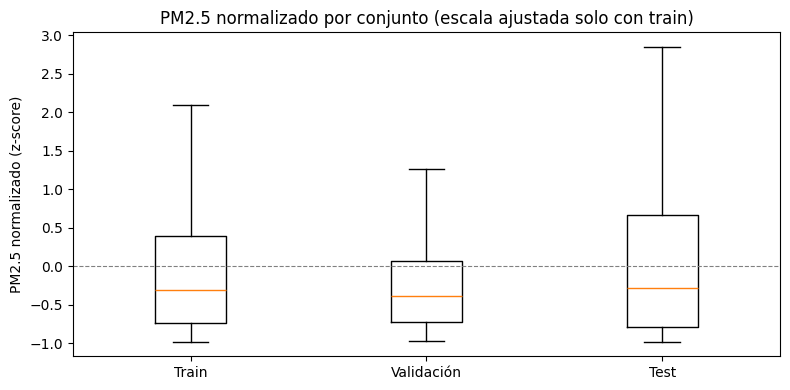

Media de PM2.5 normalizado en train (debe ser ~0): 0.0
Desv. estándar de PM2.5 normalizado en train (debe ser ~1): 1.0
Media de PM2.5 normalizado en val: -0.1993
Media de PM2.5 normalizado en test: 0.1402


In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.boxplot(
    [train_norm["PM2.5"].dropna(), val_norm["PM2.5"].dropna(), test_norm["PM2.5"].dropna()],
    labels=["Train", "Validación", "Test"],
    showfliers=False,
)
ax.axhline(0, color="gray", linewidth=0.8, linestyle="--")
ax.set_title("PM2.5 normalizado por conjunto (escala ajustada solo con train)")
ax.set_ylabel("PM2.5 normalizado (z-score)")
plt.tight_layout()
plt.show()

print("Media de PM2.5 normalizado en train (debe ser ~0):", train_norm["PM2.5"].mean().round(4))
print("Desv. estándar de PM2.5 normalizado en train (debe ser ~1):", train_norm["PM2.5"].std().round(4))
print("Media de PM2.5 normalizado en val:", val_norm["PM2.5"].mean().round(4))
print("Media de PM2.5 normalizado en test:", test_norm["PM2.5"].mean().round(4))

> En `train_norm`, la media de PM2.5 debe ser aproximadamente 0 y la desviación aproximadamente 1 porque ambas cantidades se calcularon sobre ese mismo conjunto. En validación y prueba, una media distinta de 0 no indica un fallo: se transforman con la escala histórica de entrenamiento y, por tanto, conservan posibles cambios de distribución entre periodos. Esta decisión evita fuga de información y hace que la evaluación mida la adaptación del modelo a condiciones futuras, en lugar de producir un resultado artificialmente optimista.

## 8. Construcción de ventanas

Las muestras se generan con ventanas deslizantes. Esto permite predecir a cualquier hora usando las últimas observaciones, no solo una vez por día; limitarse al día calendario eliminaría la mayoría de los ejemplos y dejaría sin representación las horas intermedias.

Las ventanas se construyen por separado dentro de cada estación.

Se comparan dos configuraciones:

- **A: 24h → 1h**, con contexto diario y horizonte corto.
- **B: 48h → 6h**, con más contexto y un horizonte más exigente.

La comparación permite comprobar si el contexto adicional ayuda o si diluye la señal reciente.

In [12]:
def construir_ventanas(data, window, horizon, features, target):
    """Construye ventanas deslizantes (X, y) sin cruzar estaciones,
    descartando cualquier ventana con NaN en X o en y."""
    X_list, y_list = [], []
    descartadas = 0
    for estacion, g in data.groupby("station"):
        g = g.sort_values("datetime")
        arr = g[features].values
        tgt = g[target].values
        n = len(g)
        for i in range(n - window - horizon + 1):
            x = arr[i:i + window]
            y = tgt[i + window + horizon - 1]
            if np.isnan(x).any() or np.isnan(y):
                descartadas += 1
                continue
            X_list.append(x)
            y_list.append(y)
    X = np.array(X_list, dtype=np.float32)
    y = np.array(y_list, dtype=np.float32)
    return X, y, descartadas


CONFIGURACIONES = {
    "A_24h_a_1h": {"window": 24, "horizon": 1},
    "B_48h_a_6h": {"window": 48, "horizon": 6},
}

resultados = {}

for nombre_config, params in CONFIGURACIONES.items():
    resultados[nombre_config] = {}
    print(f"\n=== Configuración {nombre_config} (ventana={params['window']}h, horizonte={params['horizon']}h) ===")
    for nombre_split, data in [("train", train_norm), ("val", val_norm), ("test", test_norm)]:
        X, y, descartadas = construir_ventanas(
            data, window=params["window"], horizon=params["horizon"],
            features=FEATURES, target=TARGET
        )
        resultados[nombre_config][nombre_split] = (X, y)
        print(f"  {nombre_split:5s} -> X: {X.shape} | y: {y.shape} | ventanas descartadas por NaN: {descartadas}")



=== Configuración A_24h_a_1h (ventana=24h, horizonte=1h) ===
  train -> X: (315360, 24, 11) | y: (315360,) | ventanas descartadas por NaN: 0
  val   -> X: (52704, 24, 11) | y: (52704,) | ventanas descartadas por NaN: 0
  test  -> X: (51840, 24, 11) | y: (51840,) | ventanas descartadas por NaN: 0

=== Configuración B_48h_a_6h (ventana=48h, horizonte=6h) ===
  train -> X: (315012, 48, 11) | y: (315012,) | ventanas descartadas por NaN: 0
  val   -> X: (52356, 48, 11) | y: (52356,) | ventanas descartadas por NaN: 0
  test  -> X: (51492, 48, 11) | y: (51492,) | ventanas descartadas por NaN: 0


In [13]:
# Verificación de dimensiones e integridad: cero NaN, y X/y alineados en cantidad
for nombre_config, splits in resultados.items():
    for nombre_split, (X, y) in splits.items():
        assert X.shape[0] == y.shape[0], f"Desalineación X/y en {nombre_config}/{nombre_split}"
        assert not np.isnan(X).any(), f"Quedan NaN en X de {nombre_config}/{nombre_split}"
        assert not np.isnan(y).any(), f"Quedan NaN en y de {nombre_config}/{nombre_split}"
        window_esperada = CONFIGURACIONES[nombre_config]["window"]
        n_features_esperado = len(FEATURES)
        assert X.shape[1] == window_esperada, "Longitud de ventana incorrecta"
        assert X.shape[2] == n_features_esperado, "Número de variables incorrecto"

print("Todas las configuraciones y conjuntos verificados: sin NaN, dimensiones correctas.")


Todas las configuraciones y conjuntos verificados: sin NaN, dimensiones correctas.


> Se comprueba que ambas configuraciones generan ejemplos suficientes en los tres periodos y que las formas de `X` coinciden con sus ventanas. 

> La configuración 24h→1h ofrece más muestras y un horizonte corto
> La 48h→6h usa más contexto, pero exige predecir más lejos.

> La elección final debe contrastarse con las métricas del modelo.

### Verificación visual de una ventana

Se grafica un ejemplo real de `(X, y)` ya normalizado, mostrando la ventana de entrada (PM2.5) y el punto objetivo justo después, para confirmar visualmente que no hay desfase de índice entre la entrada y el objetivo.

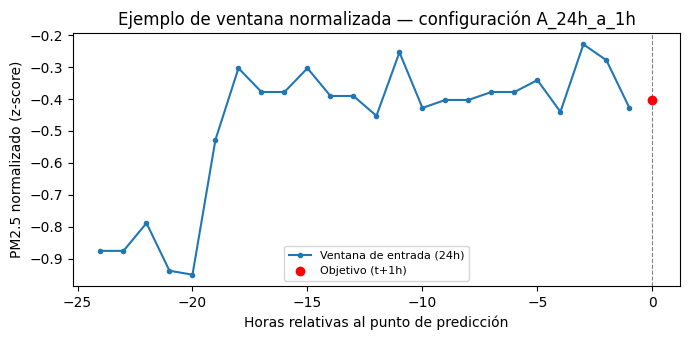

In [14]:
config_ejemplo = "A_24h_a_1h"
X_ej, y_ej = resultados[config_ejemplo]["train"]

idx = 1000  # ejemplo cualquiera dentro del conjunto
ventana_pm25 = X_ej[idx, :, FEATURES.index("PM2.5")]
objetivo = y_ej[idx]

fig, ax = plt.subplots(figsize=(7, 3.5))
horas_entrada = np.arange(-len(ventana_pm25), 0)
ax.plot(horas_entrada, ventana_pm25, marker="o", markersize=3, label="Ventana de entrada (24h)")
ax.scatter([CONFIGURACIONES[config_ejemplo]["horizon"] - 1], [objetivo], color="red", zorder=5,
           label=f"Objetivo (t+{CONFIGURACIONES[config_ejemplo]['horizon']}h)")
ax.axvline(0, color="gray", linestyle="--", linewidth=0.8)
ax.set_title(f"Ejemplo de ventana normalizada — configuración {config_ejemplo}")
ax.set_xlabel("Horas relativas al punto de predicción")
ax.set_ylabel("PM2.5 normalizado (z-score)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 9. Guardar tensores para el siguiente notebook

Se guardan pares `(X, y)` en formato PyTorch. `X` contiene secuencias con forma `(muestras, horas, variables)` y `y` contiene el PM2.5 objetivo de cada muestra.

In [15]:
PYTORCH_DIR_PATH = Path('data/pytorch_tensors')
PYTORCH_DIR_PATH.mkdir(parents=True, exist_ok=True)

for nombre_config, splits in resultados.items():
    for nombre_split, (X, y) in splits.items():
        X_t = torch.from_numpy(X)
        y_t = torch.from_numpy(y)
        torch.save({"X": X_t, "y": y_t}, PYTORCH_DIR_PATH / f"{nombre_config}_{nombre_split}.pt")

print("Tensores guardados:")
for nombre_config in CONFIGURACIONES:
    for nombre_split in ["train", "val", "test"]:
        print(f"  {nombre_config}_{nombre_split}.pt")


Tensores guardados:
  A_24h_a_1h_train.pt
  A_24h_a_1h_val.pt
  A_24h_a_1h_test.pt
  B_48h_a_6h_train.pt
  B_48h_a_6h_val.pt
  B_48h_a_6h_test.pt


## 10. Guardar las particiones

También se exportan los conjuntos tabulares ya ordenados e imputados. Estos CSV permiten inspeccionar los datos y reproducir el siguiente notebook sin repetir la carga ni la limpieza.

In [16]:
CLEANED_DATA_DIR = Path("data/processed")
CLEANED_DATA_DIR.mkdir(parents=True, exist_ok=True)

train_path = CLEANED_DATA_DIR / "train.csv"
val_path = CLEANED_DATA_DIR / "val.csv"
test_path = CLEANED_DATA_DIR / "test.csv"

train.to_csv(train_path, index=False)
val.to_csv(val_path, index=False)
test.to_csv(test_path, index=False)

print("Archivos guardados en:")
print(train_path.resolve())
print(val_path.resolve())
print(test_path.resolve())

Archivos guardados en:
/Users/diana/Study/Master/Técnicas Avanzadas de Modelado/advanced-modeling-techniques/Unidad 1: Deep learning para series de tiempo/data/processed/train.csv
/Users/diana/Study/Master/Técnicas Avanzadas de Modelado/advanced-modeling-techniques/Unidad 1: Deep learning para series de tiempo/data/processed/val.csv
/Users/diana/Study/Master/Técnicas Avanzadas de Modelado/advanced-modeling-techniques/Unidad 1: Deep learning para series de tiempo/data/processed/test.csv


### Conclusiones

El conjunto final queda organizado para modelar una tarea de predicción temporal sin mezclar pasado y futuro:

- las particiones respetan la cronología;
- los faltantes se imputan con reglas limitadas y referencias de entrenamiento;
- la estandarización usa una única escala aprendida en `train`;
- las ventanas son causales, deslizantes y no cruzan estaciones;
- las configuraciones 24h→1h y 48h→6h permiten comparar contexto y horizonte.

Los tensores guardados están listos para entrenar y evaluar modelos. La comparación definitiva entre configuraciones debe basarse en las métricas obtenidas en validación y prueba, manteniendo la misma escala y sin reajustar los parámetros con esos conjuntos.